In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [6]:
from src.util import read_video_frames, display_image, draw_bounding_box, render_scene, get_character_placeholder, pointcloud_to_mesh
from src.operations2d import get_2d_bounding_boxes, bounding_boxes_to_image_chunks, get_masks_from_image_chunks
from src.operations3d import reconstruct_meshes_for_chunks, apply_mesh_transforms, adjust_transforms_by_chunk_rotation, sam3d_transforms_to_trimesh

In [4]:
video_path = "vids/hallway_horizontal.mp4"
frame_index = 120

object_class = "wooden_cabinet"

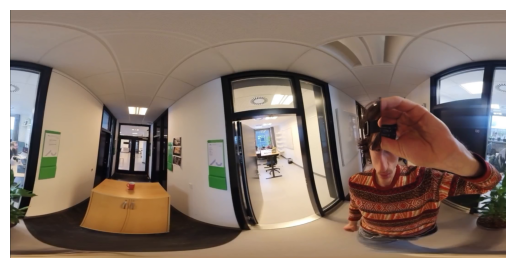

In [5]:
input_frame = read_video_frames(video_path)[frame_index]

display_image(input_frame)

# Single Class

Get panorama 2dbb and get image chunk

Running sam3 in conda environment 'sam3'...
Loading SAM3 model...
Processed chunk 1/1
Saved 1 masks and boxes



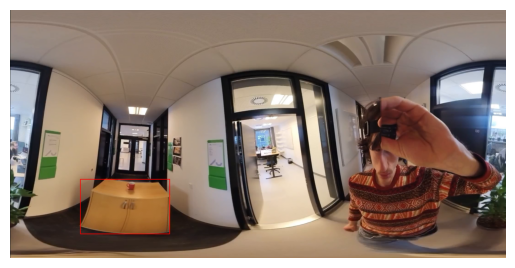

In [ ]:
# gpu
bounding_boxes = get_2d_bounding_boxes(input_frame, object_class, use_gpu=True, threshold=0.7)
frame_with_boxes = input_frame.copy()
for box in bounding_boxes:
    frame_with_boxes = draw_bounding_box(frame_with_boxes, box)

display_image(frame_with_boxes)

In [30]:
# cpu
bounding_boxes = get_2d_bounding_boxes(input_frame, object_class)
frame_with_boxes = input_frame.copy()
for box in bounding_boxes:
    frame_with_boxes = draw_bounding_box(frame_with_boxes, box)

Running dino in conda environment 'grounding_dino'...
Loading GroundingDINO model...
Using device: cpu
final text_encoder_type: bert-base-uncased
GroundingDINO model loaded.
Saved 1 bounding boxes




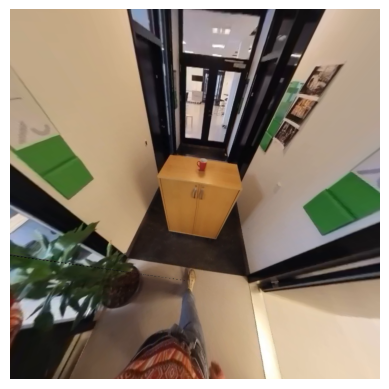

In [31]:
image_chunks = bounding_boxes_to_image_chunks(input_frame, bounding_boxes, orientation="horizontal")
display_image(image_chunks[0].image)

Get object masks

In [ ]:
# gpu
masks = get_masks_from_image_chunks(image_chunks, prompt=object_class, use_gpu=True)

Running sam3 in conda environment 'sam3'...
Loading SAM3 model...
Processed chunk 1/1
Saved 1 masks and boxes



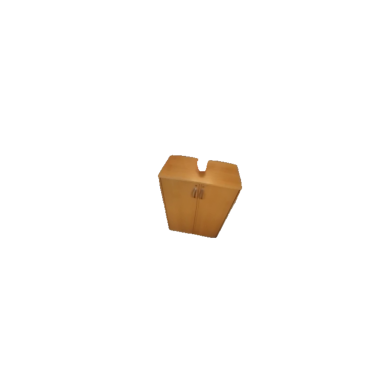

In [39]:
display_image(masks[0])

In [32]:
# cpu
masks = get_masks_from_image_chunks(image_chunks, prompt=object_class)

Running ovseg in conda environment 'ovseg'...


Generate meshes

In [ ]:
posed_meshes, unposed_meshes, scales, rotations, translations = reconstruct_meshes_for_chunks(image_chunks, masks)

In [74]:
meshes[0].export("output/cupboard.glb")

b'glTF\x02\x00\x00\x00\xa02\x11\x00p\x05\x00\x00JSON{"scene":0,"scenes":[{"nodes":[0]}],"asset":{"version":"2.0","generator":"https://github.com/mikedh/trimesh"},"accessors":[{"componentType":5125,"type":"SCALAR","bufferView":0,"count":36936,"max":[6864],"min":[0]},{"componentType":5126,"type":"VEC3","byteOffset":0,"bufferView":1,"count":6865,"max":[0.36799702048301697,2.6120567321777344,0.5503820180892944],"min":[-0.41242435574531555,1.549809455871582,-0.30478033423423767]},{"componentType":5126,"type":"VEC2","byteOffset":0,"bufferView":3,"count":6865,"max":[0.999476432800293,0.999515950679779],"min":[0.0005235602147877216,0.00048404932022094727]}],"meshes":[{"name":"reconstructed_mesh_0.glb","extras":{"units":"meters","from_gltf_primitive":false,"processed":true},"primitives":[{"attributes":{"POSITION":1,"TEXCOORD_0":2},"indices":0,"mode":4,"material":0}]}],"images":[{"bufferView":2,"mimeType":"image/png"}],"textures":[{"source":0}],"materials":[{"pbrMetallicRoughness":{"baseColorTex

In [ ]:
# convert transforms to trimesh space, then adjust by chunk rotation
trimesh_transforms = [
    sam3d_transforms_to_trimesh(scale, rotation, translation)
    for scale, rotation, translation in zip(scales, rotations, translations)
]
trimesh_scales = [item[0] for item in trimesh_transforms]
trimesh_rotations = [item[1] for item in trimesh_transforms]
trimesh_translations = [item[2] for item in trimesh_transforms]

adjusted_rotations, adjusted_translations = adjust_transforms_by_chunk_rotation(
    trimesh_rotations, trimesh_translations, image_chunks[0]
)
adjusted_meshes = [
    apply_mesh_transforms(mesh, rot, trans, scale)
    for mesh, scale, rot, trans in zip(
        unposed_meshes, trimesh_scales, adjusted_rotations, adjusted_translations
    )
]

In [96]:
adjusted_meshes[0].export("output/cupboard_adjusted.glb")

b'glTF\x02\x00\x00\x00\x842\x11\x00T\x05\x00\x00JSON{"scene":0,"scenes":[{"nodes":[0]}],"asset":{"version":"2.0","generator":"https://github.com/mikedh/trimesh"},"accessors":[{"componentType":5125,"type":"SCALAR","bufferView":0,"count":36936,"max":[6864],"min":[0]},{"componentType":5126,"type":"VEC3","byteOffset":0,"bufferView":1,"count":6865,"max":[0.16750375926494598,0.7118450999259949,1.1293054819107056],"min":[-0.20090115070343018,0.4620252847671509,0.5921303033828735]},{"componentType":5126,"type":"VEC2","byteOffset":0,"bufferView":3,"count":6865,"max":[0.999476432800293,0.999515950679779],"min":[0.0005235602147877216,0.00048404932022094727]}],"meshes":[{"name":"geometry_0","extras":{"units":"meters","from_gltf_primitive":false,"processed":true},"primitives":[{"attributes":{"POSITION":1,"TEXCOORD_0":2},"indices":0,"mode":4,"material":0}]}],"images":[{"bufferView":2,"mimeType":"image/png"}],"textures":[{"source":0}],"materials":[{"pbrMetallicRoughness":{"baseColorTexture":{"index":

Render Scene

In [95]:
import open3d as o3d
from src.util import trimesh_to_open3d
character_placeholder = get_character_placeholder()
coordinate_frame = o3d.geometry.TriangleMesh.create_coordinate_frame(size=0.55, origin=[0, 0, 0])

scene_meshes = [trimesh_to_open3d(mesh) for mesh in adjusted_meshes]

render_scene(scene_meshes + [character_placeholder, coordinate_frame])

# Multiple Classes

In [ ]:
from src.tracking import reconstruct_meshes_for_class

In [ ]:
cupboard_meshes = adjusted_meshes

In [ ]:
cup_meshes = reconstruct_meshes_for_class(input_frame, "cup")

Running dino in conda environment 'grounding_dino'...
Loading GroundingDINO model...
Using device: cuda
final text_encoder_type: bert-base-uncased
GroundingDINO model loaded.
Saved 1 bounding boxes

Running ovseg in conda environment 'ovseg'...
Loading OV-Seg model...
OV-Seg model loaded.
Processed chunk 1/1
Saved 1 masks

Running sam3d in conda environment 'sam3d-objects'...
Warp 1.12.0 initialized:
   CUDA Toolkit 12.9, Driver 12.8
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA L4" (22 GiB, sm_89, mempool enabled)
   Kernel cache:
     /home/ucloud/.cache/warp/1.12.0
[SPARSE][CONV] spconv algo: auto
Saved point cloud 1/1 to temp/sam3d_output/reconstructed_mesh_0.ply
Generated 1 point clouds



In [ ]:
o3d.io.write_triangle_mesh("output/cup.glb", cup_meshes[0])

True

In [ ]:
all_meshes = cupboard_meshes + cup_meshes

In [ ]:
import open3d as o3d
character_placeholder = get_character_placeholder()
coordinate_frame = o3d.geometry.TriangleMesh.create_coordinate_frame(size=0.5, origin=[0, 0, 0])

scene_meshes = all_meshes

render_scene(scene_meshes + [character_placeholder, coordinate_frame])